<a href="https://colab.research.google.com/github/LMariano418/LMariano418/blob/main/profissao_cientista_de_dados_m15_pratique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [ ]:
import pandas as pd
#Seu código de importação aqui
df = pd.read_csv('/content/CHURN_TELECON_MOD08_TAREFA_cleaned.csv', delimiter=',')

# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

DataFrame Columns after stripping whitespace: Index(['customer_id', 'genero', 'idoso', 'casado', 'dependents',
       'tempo_cliente', 'phone_service', 'internet_service', 'seguranca',
       'suporte_tecnico', 'streaming_tv', 'tipo_contrato', 'metodo_pagamento',
       'pagamento_mensal', 'total_pago', 'churn'],
      dtype='object')


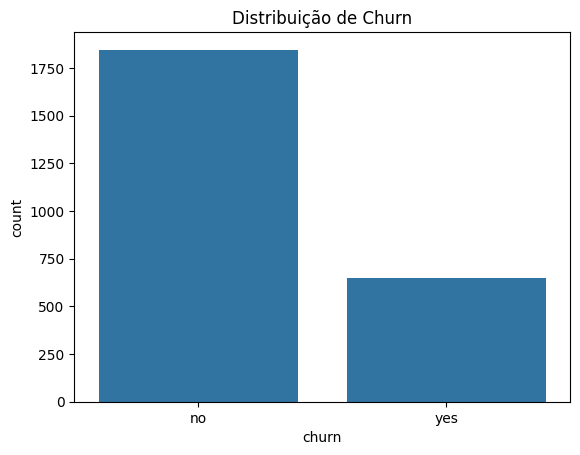

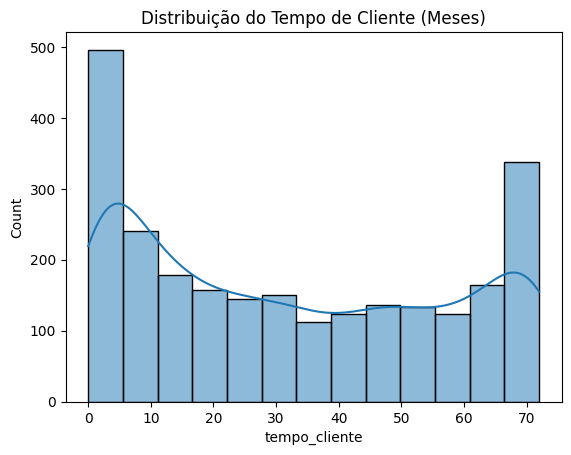

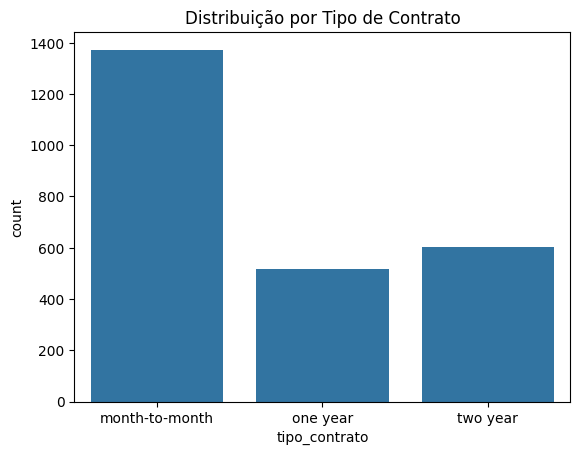

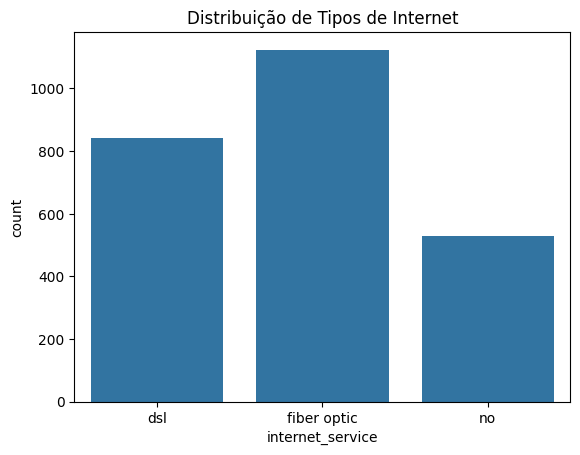

idoso
0    0.838878
1    0.161122
Name: proportion, dtype: float64
casado
no     0.507415
yes    0.492585
Name: proportion, dtype: float64


In [ ]:
#Seu código aqui
df.describe()
# Insights:
# - tempo_cliente varia de 1 a 72 meses.
# - pagamento_mensal apresenta uma média de 71.45, que parece ser um valor muito repetitivo.
# A variável pagamento_mensal possui uma concentração atípica no valor 71.45 em quase todas as entradas iniciais, o que indica uma possível anomalia

# Fix: Strip whitespace from column names to ensure 'churn' is correctly identified
df.columns = df.columns.str.strip()
print("DataFrame Columns after stripping whitespace:", df.columns)

sns.countplot(data=df, x='churn')
plt.title('Distribuição de Churn')
plt.show()

sns.histplot(df['tempo_cliente'], kde=True)
plt.title('Distribuição do Tempo de Cliente (Meses)')
plt.show()

sns.countplot(data=df, x='tipo_contrato')
plt.title('Distribuição por Tipo de Contrato')
plt.show()

sns.countplot(data=df, x='internet_service')
plt.title('Distribuição de Tipos de Internet')
plt.show()


print(df['idoso'].value_counts(normalize=True))
print(df['casado'].value_counts(normalize=True))
# Insight: A maioria dos clientes não é idosa (valor 0).


# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


In [ ]:
# Devido à repetição extrema do valor 71.45 em 'pagamento_mensal',
# uma sugestão de abordagem seria substituir por NaN e tratar ou remover se for erro.
df.loc[df['pagamento_mensal'] == 71.45, 'pagamento_mensal'] = np.nan
df = df.dropna(subset=['pagamento_mensal']) # Decisão de remoção para limpeza

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

<Axes: xlabel='tipo_contrato', ylabel='count'>

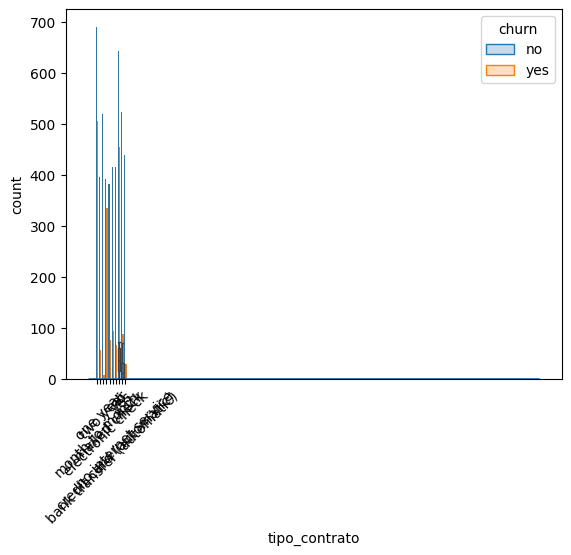

In [ ]:
sns.countplot(data=df, x='tipo_contrato', hue='churn')

sns.countplot(data=df, x='metodo_pagamento', hue='churn')
plt.xticks(rotation=45)

sns.countplot(data=df, x='seguranca', hue='churn')

sns.boxplot(data=df, x='churn', y='tempo_cliente')

sns.kdeplot(data=df, x='pagamento_mensal', hue='churn', fill=True)

#Com base nos dados, as variáveis mais críticas para o Churn parecem ser tipo_contrato, tempo_cliente, internet_service e pagamento_mensal




## 5) Adicional para estudo - Calculo de correlação entre as variáveis numéricas e o churn

In [ ]:
import pandas as pd
import numpy as np
# Converter a variável 'churn' para numérica (0 e 1)
# Diagnóstico: Verificar o conteúdo do churn original antes de encodificar
print("Value counts for original 'churn' column:")
print(df['churn'].value_counts(dropna=False))

df['churn_encoded'] = df['churn'].apply(lambda x: 1 if str(x).lower() == 'yes' else 0)

# Diagnóstico: Verificar o conteúdo de 'churn_encoded'
print("\nValue counts for churn_encoded:")
print(df['churn_encoded'].value_counts(dropna=False))
print("\nNumber of NaN values in churn_encoded:", df['churn_encoded'].isnull().sum())

# Selecionar apenas as colunas numéricas para o cálculo da correlação
# Incluir 'churn_encoded' na seleção
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Calcular a matriz de correlação
correlation_matrix = df[numeric_cols].corr()

# Exibir a correlação das variáveis com 'churn_encoded'
print("\nCorrelação das variáveis numéricas com Churn:")
display(correlation_matrix['churn_encoded'].sort_values(ascending=False))

Value counts for original 'churn' column:
churn
no     1604
yes     570
Name: count, dtype: int64

Value counts for churn_encoded:
churn_encoded
0    1604
1     570
Name: count, dtype: int64

Number of NaN values in churn_encoded: 0

Correlação das variáveis numéricas com Churn:


,churn_encoded
churn_encoded,1.000000
pagamento_mensal,0.218300
idoso,0.123915
total_pago,-0.181915
tempo_cliente,-0.339591


### Insights da Correlação:
*   **tempo_cliente (Customer Tenure):** Possui uma correlação negativa significativa com o churn. Isso indica que clientes com mais tempo de serviço são menos propensos a churnar, o que é esperado.
*   **pagamento_mensal (Monthly Charges):** Apresenta uma correlação positiva moderada com o churn. Clientes com pagamentos mensais mais altos podem ter uma maior propensão a churnar.
*   **idoso (Senior Citizen):** Tem uma correlação positiva baixa, sugerindo que clientes idosos podem ter uma leve tendência a churnar mais do que os não idosos.
*   As outras variáveis numéricas mostram correlações muito baixas, indicando que sua relação linear com o churn não é forte.